In [1]:
import importlib
import matplotlib.pyplot as plt
import sys
import numpy as np
sys.path.append('./src')
import maths_utils as math_utils
importlib.reload(math_utils)

<module 'maths_utils' from '/Users/edouardblanc/Desktop/machine_learning/dl_from_scratch/src/maths_utils.py'>

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

boston = fetch_california_housing()
data = boston.data
target = boston.target
features = boston.feature_names
s = StandardScaler()
data = s.fit_transform(data)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=80718)

y_train, y_test = y_train.reshape(-1, 1), y_test.reshape(-1, 1)
features

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

Text(0.5, 1.0, 'Validation Scores')

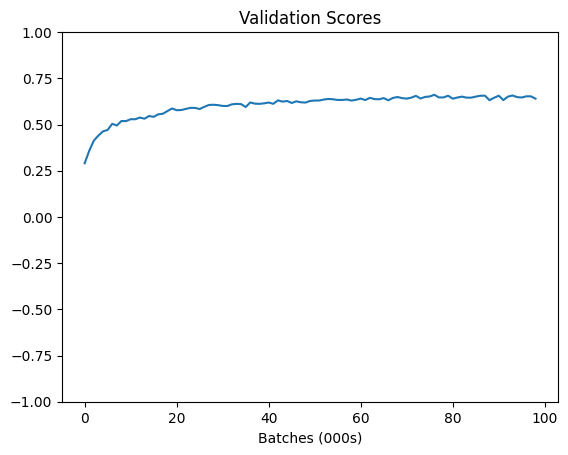

In [15]:
import neural_network_utils as nn_utils
importlib.reload(nn_utils)
num_iter = 100000
test_every = 1000
train_info = nn_utils.train(X_train, y_train, X_test, y_test,
                    n_iter=num_iter,
                    test_every = test_every,
                    learning_rate = 0.001,
                    batch_size=23, 
                    return_losses=True, 
                    return_weights=True, 
                    return_scores=True,
                    seed=80718)
losses = train_info[0]
weights = train_info[1]
val_scores = train_info[2]
plt.ylim([-1,1])
plt.plot(list(range(int(num_iter / test_every - 1))), val_scores); 
plt.xlabel("Batches (000s)")
plt.title("Validation Scores")

Mean absolute error: 0.4054 
Root mean squared error: 0.589


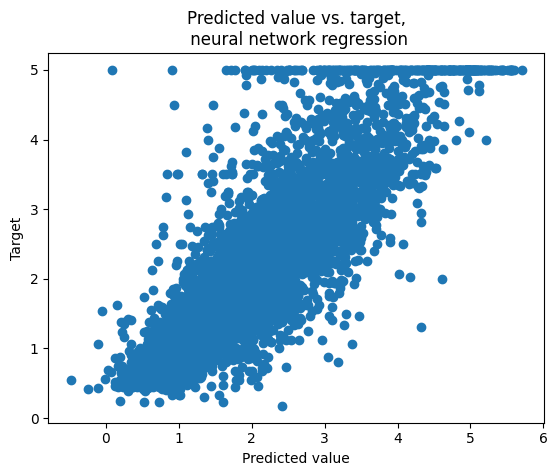

In [18]:
preds = nn_utils.predict(X_test, weights)
plt.xlabel("Predicted value")
plt.ylabel("Target")
plt.title("Predicted value vs. target,\n neural network regression")
plt.scatter(preds, y_test)
print("Mean absolute error:", round(math_utils.mae(preds, y_test), 4), "\n"
      "Root mean squared error:", round(math_utils.rmse(preds, y_test), 4))